In [2]:
import os
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib_venn

# helper script module that incorporates pandas read-in and adding/separating fields
# copied over from 20230901, can eventually be shuttled off to its own special directory if it stays in use
import parsing_utils as parse

# Intersecting benchmarks with Sniffles output

First, I tried `bedtools intersect` and that was Not It. Time to move on to intersection of the simulation VCF and the Tier 1 SV callset VCF with something like `svpop`.

I edited the configfiles for `svpop` stored in `config/packages/svpop/*`: had to update `samples.tsv` to reflect that I'm no longer trying to merge a bunch of not useful callsets from other non-mosaic callers.

Next, had to edit the relevant reference to be `CHM13`. PAV is built on top of `hg38` no ALTs, but... hopefully it works? I could try `SURVIVOR` or `truvari` too.

```
# svpop
# config: code/svpop/config/config.json
# sample table: code/svpop/config/samples.tsv (double check this aligns with current sample table?)

ln -s /global/scratch/users/stacy-l/spermSV/config/packages/svpop/config.json code/svpop/config/config.json
ln -s /global/scratch/users/stacy-l/spermSV/config/packages/svpop/samples.tsv code/svpop/config/samples.tsv
cd code/svpop

# uses default szro params
# I am shocked and amazed that this worked

# insertion intersect
snakemake -pj40 --keep-going --use-conda -s Snakefile results/variant/intersect/caller+sniffles_mosaic+HG002_894_simulation/caller+giab_CMRG+HG002/szro-default/all/all/sv_ins/intersect.tsv.gz results/variant/intersect/caller+sniffles_mosaic+HG002_894_simulation/caller+giab_SVTier1+HG002/szro-default/all/all/sv_ins/intersect.tsv.gz results/variant/intersect/caller+sniffles_germline+HG002/caller+giab_CMRG+HG002/szro-default/all/all/sv_ins/intersect.tsv.gz results/variant/intersect/caller+sniffles_germline+HG002/caller+giab_SVTier1+HG002/szro-default/all/all/sv_ins/intersect.tsv.gz
cd ../..

# move the insertion intersect files to the current notebook directory
mv code/svpop/results/variant/intersect/caller+sniffles_mosaic+HG002_894_simulation/caller+giab_CMRG+HG002/szro-default/all/all/sv_ins/intersect.tsv.gz notebooks/jupyter/20230915/simulation_giab_CMRG_CHM13_intersect_ins.tsv.gz
mv code/svpop/results/variant/intersect/caller+sniffles_mosaic+HG002_894_simulation/caller+giab_SVTier1+HG002/szro-default/all/all/sv_ins/intersect.tsv.gz notebooks/jupyter/20230915/simulation_giab_SVTier1_CHM13_intersect_ins.tsv.gz
mv code/svpop/results/variant/intersect/caller+sniffles_germline+HG002/caller+giab_CMRG+HG002/szro-default/all/all/sv_ins/intersect.tsv.gz notebooks/jupyter/20230915/germline_giab_CMRG_CHM13_intersect_ins.tsv.gz
mv code/svpop/results/variant/intersect/caller+sniffles_germline+HG002/caller+giab_SVTier1+HG002/szro-default/all/all/sv_ins/intersect.tsv.gz notebooks/jupyter/20230915/germline_giab_SVTier1_CHM13_intersect_ins.tsv.gz


# make copies of the "standardized" variant IDs generated by svpop
cp code/svpop/results/variant/caller/giab_CMRG/HG002/all/all/bed/sv_ins.bed.gz notebooks/jupyter/20230915/giab_CMRG_ins_svpop.bed.gz
cp code/svpop/results/variant/caller/giab_SVTier1/HG002/all/all/bed/sv_ins.bed.gz notebooks/jupyter/20230915/giab_SVTier1_ins_svpop.bed.gz
cp code/svpop/results/variant/caller/sniffles_germline/HG002/all/all/bed/sv_ins.bed.gz notebooks/jupyter/20230915/germline_ins_svpop.bed.gz
cp code/svpop/results/variant/caller/sniffles_mosaic/HG002_894_simulation/all/all/bed/sv_ins.bed.gz notebooks/jupyter/20230915/simulation_ins_svpop.bed.gz
```

# Examining the benchmark files
Using the `svpop`-formatted bedfiles, because those have `SVTYPE` and `SVLEN` fields pre-populated.

## Insertions

In [3]:
svpop_CMRG_ins = pd.read_table("giab_CMRG_ins_svpop.bed.gz")
svpop_CMRG_ins.head()

,#CHROM,POS,END,ID,SVTYPE,SVLEN,REF,ALT,QUAL,FILTER,VCF_ALT_IDX,VARTYPE,VCF_POS,VCF_REF,VCF_ALT,VCF_IDX
0,chr1,23719463,23719464,chr1-23719464-INS-2151,INS,2151,NaN,<INS>,30,PASS,1,SV,23719463,T,TTAGAGGCGTGAGCCACTACACCTGGCTATGTATACTTTAGTGATT...,0
1,chr1,25241875,25241876,chr1-25241876-INS-109,INS,109,NaN,<INS>,30,PASS,1,SV,25241875,T,TGCAATGAGCTATGATTGTACCACTGGGAAGTGACAAAGGGCACCC...,1
2,chr1,203459368,203459369,chr1-203459369-INS-381,INS,381,NaN,<INS>,30,PASS,1,SV,203459368,T,TACACACACACACCACACACATATACACACATACACCCATACACAC...,2
3,chr1,203459368,203459369,chr1-203459369-INS-455,INS,455,NaN,<INS>,30,PASS,1,SV,203459368,T,TACACACACATCATACACACACACACCACACACATATATACGCACA...,3
4,chr10,134328044,134328045,chr10-134328045-INS-106,INS,106,NaN,<INS>,30,PASS,1,SV,134328044,G,GGGGGGGTGCGGGGTCAGGCGGGGGGGTGCGGGGTCAGGTGGGGGG...,78


In [4]:
svpop_SVTier1_ins = pd.read_table("giab_SVTier1_ins_svpop.bed.gz")
svpop_SVTier1_ins.head()

,#CHROM,POS,END,ID,SVTYPE,SVLEN,REF,ALT,QUAL,FILTER,VCF_ALT_IDX,VARTYPE,VCF_POS,VCF_REF,VCF_ALT,VCF_IDX
0,chr1,405395,405396,chr1-405396-INS-919,INS,919,NaN,<INS>,10,PASS,1,SV,405395,G,GCCCCGGGAACCGCCTGCCCCCACCCCCACCAACCCCAGGAACCGC...,13
1,chr1,426134,426135,chr1-426135-INS-196,INS,196,NaN,<INS>,10,PASS,1,SV,426134,A,AGGGAGGGCAGAAAGGACCCCCACGTGAGGGGGCACCCCACATCTG...,17
2,chr1,428922,428923,chr1-428923-INS-57,INS,57,NaN,<INS>,20,PASS,1,SV,428922,A,AGGGCGCGGAGCGGAGGGGAGGGCGCGGAGCGGAGGGGAGGGCGCG...,18
3,chr1,495328,495329,chr1-495329-INS-272,INS,272,NaN,<INS>,10,PASS,1,SV,495328,G,GCGGGGCCCTGGGGGGTGTGGTGGGGTCTGCGGGCCCTGGGGGGGT...,21
4,chr1,498839,498840,chr1-498840-INS-78,INS,78,NaN,<INS>,20,PASS,1,SV,498839,G,GGCCACGCGGGCTGTGCAGATGCAGGTGCGGCGGGGCGGGGCCACG...,23


# Examining & annotating the simulation file
The `svpop`-formatted simulation bedfile needs to be annotated with the origin of each SV called by sniffles, as we did before with `RNAMES` in the direct-from-Sniffles VCF.

In [5]:
# I forgot that I gave svpop the input *without* censats removed, but you know what, it wasn't even that useful, so maybe that's fine.
# we don't need to run the filters here, we should have a sort of filter-agnostic approach when examining intersects with the benchmarks
# we could be surprised!

simulation_raw = parse.variant_table('/Users/stacyli/savio/global/scratch/stacy-l/spermSV/output/mapping/CHM13/sniffles/mosaic/single_sample/HG002_894_simulation.vcf.gz')
svpop_simulation_ins = pd.read_table("simulation_ins_svpop.bed.gz")

# annotate svpop_simulation_ins with ORIGIN and RNAMES, using VCF_IDX as a key to match index values of simulation_raw VCF
svpop_simulation_ins = pd.merge(svpop_simulation_ins, simulation_raw[['ORIGIN', 'RNAMES']], left_on = 'VCF_IDX', right_index = True)
svpop_simulation_ins.head()

,#CHROM,POS,END,ID,SVTYPE,SVLEN,REF,ALT,QUAL,FILTER,VCF_ALT_IDX,VARTYPE,VCF_POS,VCF_REF,VCF_ALT,VCF_IDX,ORIGIN,RNAMES
0,chr1,36605,36606,chr1-36606-INS-876,INS,876,NaN,<INS>,57,PASS,1,SV,36605,N,GGCGGCACACGCGGGTTCTCTGTGGCCAGCAGGCGGCGCTGCAGGA...,0,894,"894/227216994/ccs,894/206902104/ccs,894/176952..."
1,chr1,90774,90775,chr1-90775-INS-76,INS,76,NaN,<INS>,60,PASS,1,SV,90774,N,GGGGTAGGAGACCATCAGGACAAACACGTGGATACATGGAGGGGAA...,1,894,"894/232981007/ccs,894/49681026/ccs"
2,chr1,306175,306176,chr1-306176-INS-369,INS,369,NaN,<INS>,60,PASS,1,SV,306175,N,CTCGCCCACACTCCCCCACACTCCCTCACAGTCGCCCACACTCCCC...,9,894,"894/37424372/ccs,894/200349227/ccs,894/1121329..."
3,chr1,339098,339099,chr1-339099-INS-87,INS,87,NaN,<INS>,60,PASS,1,SV,339098,N,CCCGGGCGCACCGTTGCTGGTATATGCGGGGGTCGGGGTCAGGCCC...,10,894,"894/136909569/ccs,894/37752089/ccs"
4,chr1,363598,363599,chr1-363599-INS-86,INS,86,NaN,<INS>,60,PASS,1,SV,363598,N,CGTTACAGGTGGGCAGGGGAGGCTGCTCCGTACAGGTGGGCAGGGG...,11,894,894/9177661/ccs


# Examining and annotating the germline file
Same deal as above: we're not so much interested in `ORIGIN`, only `RNAMES` for the sake of having insight into how SVs were called by `sniffles`.

In [6]:
germline_raw = parse.variant_table('/Users/stacyli/savio/global/scratch/stacy-l/spermSV/output/mapping/CHM13/sniffles/standard/single_sample/HG002.vcf.gz')
svpop_germline_ins = pd.read_table("germline_ins_svpop.bed.gz")

# annotate svpop_germline_ins with ORIGIN and RNAMES, using VCF_IDX as a key to match index values of simulation_raw VCF
svpop_germline_ins = pd.merge(svpop_germline_ins, germline_raw[['ORIGIN', 'RNAMES']], left_on = 'VCF_IDX', right_index = True)
svpop_germline_ins.head()

,#CHROM,POS,END,ID,SVTYPE,SVLEN,REF,ALT,QUAL,FILTER,VCF_ALT_IDX,VARTYPE,VCF_POS,VCF_REF,VCF_ALT,VCF_IDX,ORIGIN,RNAMES
0,chr1,18082,18083,chr1-18083-INS-315,INS,315,NaN,<INS>,60,PASS,1,SV,18082,N,AGAAGGAATAAGACGGGCCGGGTGCGGTGGCTCACGCCTGTAATCC...,3,HG002,"HG002/74976573/ccs,HG002/118818109/ccs,HG002/1..."
1,chr1,27952,27953,chr1-27953-INS-499,INS,499,NaN,<INS>,60,PASS,1,SV,27952,N,ACCTCAGGGTCCATTCTGATCTGTATATATGTATCATGTAAACACG...,6,HG002,"HG002/229970239/ccs,HG002/101125604/ccs,HG002/..."
2,chr1,29293,29294,chr1-29294-INS-73,INS,73,NaN,<INS>,57,PASS,1,SV,29293,N,CCCTCTCCTTTCTCCTCTCTAGCCCCCTCTCCTTTCTCCTCTCTAT...,7,HG002,"HG002/53352110/ccs,HG002/55710083/ccs,HG002/25..."
3,chr1,36632,36633,chr1-36633-INS-876,INS,876,NaN,<INS>,60,PASS,1,SV,36632,N,GGCGGCACACGCGGGTTCTCTGTGGCCAGCAGGCGGCGCTGCAGGA...,9,HG002,"HG002/46924279/ccs,HG002/101125604/ccs,HG002/1..."
4,chr1,37638,37639,chr1-37639-INS-726,INS,726,NaN,<INS>,60,PASS,1,SV,37638,N,TGGGTGTGACGGGGTGTGTTCTGTGTGAGAACATGTGTGTAGTGTC...,10,HG002,"HG002/46924279/ccs,HG002/124326208/ccs,HG002/5..."


# Examining the intersection files
Time to look at everything!

For all files, `ID_A` refers to the ID in the simulation, and `ID_B` is the ID in the benchmark. All intersects are test examinations of **insertions only**.

## Germline HG002 calls <-> GIAB CMRG

In [7]:
germline_giab_CMRG_intersect_ins_all = pd.read_table("germline_giab_CMRG_CHM13_intersect_ins.tsv.gz")

# filter to only intersected variants + merge with select columns from svpop_germline_ins using ID_A as a key
germline_giab_CMRG_intersect_ins = pd.merge(germline_giab_CMRG_intersect_ins_all.query("SOURCE_SET == 'A,B'"), svpop_germline_ins[['ID', 'SVTYPE', 'SVLEN', 'ORIGIN', 'RNAMES']], left_on = 'ID_A', right_on = 'ID')
print('Total intersected:', germline_giab_CMRG_intersect_ins.shape[0], "/", svpop_CMRG_ins.shape[0])

Total intersected: 47 / 123


## Germline HG002 calls <-> GIAB SV Tier 1

In [8]:
germline_giab_SVTier1_intersect_ins_all = pd.read_table("germline_giab_SVTier1_CHM13_intersect_ins.tsv.gz")

# filter to only intersected variants + merge with select columns from svpop_germline_ins using ID_A as a key
germline_giab_SVTier1_intersect_ins = pd.merge(germline_giab_SVTier1_intersect_ins_all.query("SOURCE_SET == 'A,B'"), svpop_germline_ins[['ID', 'SVTYPE', 'SVLEN', 'ORIGIN', 'RNAMES']], left_on = 'ID_A', right_on = 'ID')
print('Total intersected:', germline_giab_SVTier1_intersect_ins.shape[0], "/", svpop_SVTier1_ins.shape[0])

Total intersected: 2179 / 6346


## Simulation <-> GIAB CMRG

In [9]:
simulation_giab_CMRG_intersect_ins_all = pd.read_table("simulation_giab_CMRG_CHM13_intersect_ins.tsv.gz")

# filter to only intersected variants + merge with select columns from svpop_simulation_ins using ID_A as a key
# finally, query to filter out only HG002 calls
simulation_giab_CMRG_intersect_ins = pd.merge(simulation_giab_CMRG_intersect_ins_all.query("SOURCE_SET == 'A,B'"), svpop_simulation_ins[['ID', 'SVTYPE', 'SVLEN', 'ORIGIN', 'RNAMES']], left_on = 'ID_A', right_on = 'ID').query("ORIGIN == 'HG002'")
print('Total intersected:', simulation_giab_CMRG_intersect_ins.shape[0], "/", svpop_CMRG_ins.shape[0])


Total intersected: 4 / 123


In [10]:
# How many of the simulation's "true calls" also found in the germline sample's "true calls"?
# Below, take the intersection table above and use the benchmark's IDs ("ID_B") as a key to search for outcomes in the germline-benchmark intersection table.
germline_giab_CMRG_intersect_ins.set_index('ID_B').loc[simulation_giab_CMRG_intersect_ins['ID_B']].query(("SOURCE_SET == 'A,B'"))

,ID_A,SOURCE_SET,RO,OFFSET,SZRO,OFFSZ,MATCH,ID,SVTYPE,SVLEN,ORIGIN,RNAMES
ID_B,,,,,,,,,,,,
chr19-61584262-INS-168,chr19-61584303-INS-112,"A,B",0.67,41.0,0.67,0.37,NaN,chr19-61584303-INS-112,INS,112,HG002,"HG002/88543121/ccs,HG002/32573100/ccs,HG002/15..."
chr6-151002842-INS-305,chr6-151002843-INS-305,"A,B",1.00,1.0,1.00,0.00,NaN,chr6-151002843-INS-305,INS,305,HG002,"HG002/185666544/ccs,HG002/6099168/ccs,HG002/17..."
chr8-1675459-INS-392,chr8-1675501-INS-391,"A,B",0.89,42.0,1.00,0.11,NaN,chr8-1675501-INS-391,INS,391,HG002,"HG002/36835557/ccs,HG002/157552328/ccs,HG002/2..."
chr9-140560861-INS-122,chr9-140560862-INS-121,"A,B",0.99,1.0,0.99,0.01,NaN,chr9-140560862-INS-121,INS,121,HG002,"HG002/188549485/ccs,HG002/6751847/ccs,HG002/11..."


## Simulation <-> GIAB SV Tier 1 ("high confidence" SV callset)

In [11]:
simulation_giab_SVTier1_intersect_ins_all = pd.read_table("simulation_giab_SVTier1_CHM13_intersect_ins.tsv.gz")

# filter to only intersected variants + merge with select columns from svpop_simulation_ins using ID_A as a key
# finally, query to filter out only HG002 calls
simulation_giab_SVTier1_intersect_ins = pd.merge(simulation_giab_SVTier1_intersect_ins_all.query("SOURCE_SET == 'A,B'"), svpop_simulation_ins[['ID', 'SVTYPE', 'SVLEN', 'ORIGIN', 'RNAMES']], left_on = 'ID_A', right_on = 'ID').query("ORIGIN == 'HG002'")
print('Total intersected:', simulation_giab_SVTier1_intersect_ins.shape[0], "/", svpop_SVTier1_ins.shape[0])

Total intersected: 380 / 6346


In [12]:
# How many of the simulation's "true calls" also found in the germline sample's "true calls"?
# Below, take the intersection table above and use the benchmark's IDs ("ID_B") as a key to search for outcomes in the germline-benchmark intersection table.

germline_giab_SVTier1_intersect_ins.set_index('ID_B').loc[simulation_giab_SVTier1_intersect_ins['ID_B']]

KeyError: "['chr1-222826626-INS-91', 'chr11-76094625-INS-96', 'chr16-56812003-INS-121', 'chr19-3152539-INS-351', 'chr19-52702081-INS-51', 'chr4-14776657-INS-58', 'chr7-1095092-INS-270'] not in index"

Interestingly, not all of the simulation-intersected calls were also found in the germline-intersected calls, despite my assumption that the simulation-intersected calls should either be equivalent or subset from the germline-intersected calls.

The 7 "missing" calls (called in simulation but not in germline) are below:

In [ ]:
simulation_giab_SVTier1_intersect_ins.set_index('ID_B').loc[['chr1-222826626-INS-91', 'chr11-76094625-INS-96', 'chr16-56812003-INS-121', 'chr19-3152539-INS-351', 'chr19-52702081-INS-51', 'chr4-14776657-INS-58', 'chr7-1095092-INS-270']]

Where did those specific reads go? Were they assigned to other calls in the germline output?

In [ ]:
simulation_giab_SVTier1_intersect_ins.set_index('ID_B').loc[['chr1-222826626-INS-91', 'chr11-76094625-INS-96', 'chr16-56812003-INS-121', 'chr19-3152539-INS-351', 'chr19-52702081-INS-51', 'chr4-14776657-INS-58', 'chr7-1095092-INS-270']][['ID_A', 'RNAMES']]

*(cue me manually doing this for all of the IDs because I can't be bothered to do something elegant)*

```
# check germline <-> SV Tier 1 intersection table
# question: did the read support a different (but existing and true) germline call?
germline_giab_SVTier1_intersect_ins[germline_giab_SVTier1_intersect_ins['RNAMES'].str.contains(# RNAME HERE)]

# check germline sniffles VCF -> svpop formatted bedfile
# question: did the read support ANY germline call?
svpop_germline_ins[svpop_germline_ins['RNAMES'].str.contains(# RNAME HERE)]
```

`ID_B` below is the SV Tier 1 benchmark ID assigned by `svpop`, where this ID was matched in the simulation <-> SV Tier 1 intersect table.
`ID_A` is the `sniffles` simulation VCF ID assigned by `svpop`.
For the 4th column, this ID represents the SV Tier 1 benchmark ID assigned by `svpop`.
For the 5th column, these IDs correspond to `ID_A` (`sniffles` germline VCF ID assigned by `svpop`).

|    ID_B (SV Tier 1)     |  ID_A (simulation)       |       RNAMES          |   germline-SV Tier 1 intersect (ID_B)  |   germline (all calls, ID_A)   |
|-------------------------|--------------------------|-----------------------|-----------------------------------|--------------------------|
| chr1-222826626-INS-91   | chr1-222826438-INS-91    | HG002/152307767/ccs   |               None                |           None           |
| chr11-76094625-INS-96   | chr11-76094611-INS-99    | HG002/162140876/ccs   |               None                |  chr11-76094158-INS-161  |
| chr16-56812003-INS-121  | chr16-56812193-INS-78    | HG002/174396290/ccs   |      chr16-56817487-INS-83        |  chr16-56812193-INS-596, chr16-56817640-INS-82 (matches SV Tier 1 chr16-56817487-INS-83)  |
| chr19-3152539-INS-351   | chr19-3152689-INS-376	 | HG002/84350468/ccs    |               None                |  chr19-3153075-INS-427  |
| chr19-52702081-INS-51   | chr19-52702226-INS-79    | HG002/209719381/ccs   |               None                |  chr19-52701006-INS-91, chr19-52701935-INS-298  |
| chr4-14776657-INS-58    | chr4-14776660-INS-51	 | HG002/32377520/ccs    |               None                |  chr4-14766808-INS-56  |
| chr7-1095092-INS-270    | chr7-1095161-INS-272	 | HG002/125113012/ccs   |               None                |  chr7-1094855-INS-273  |

*How can we interpret this?*

> There are seven simulation-benchmark-intersected variants in the benchmark that are **not** germline-benchmark-intersected.
> It appears that the (single) reads supporting each of the simulation-matched variants have one of tjhree (interesting?) fates:
> 1) (*1st row*) The read does not support *any* germline SV call (?!) A rare example of a germline mode false negative: where did this read go, if it doesn't support any calls? Why was it discarded?
> 2) (*3rd row*`) The read supports a different germline-benchmark-intersected variant. Emphasis that this is a *real variant* denoted in the benchmark, and it's proximal to the simulation&benchmark variant supported by the read in the simulation calls.
> 3) (*2nd-7th rows*)The read supports a germline variant called by `sniffles` that does *not* intersect with a variant in the SV Tier 1 benchmark. **Note that the 3rd row read supports both a germine-benchmark-intersected and an upstream germline non-intersected variant.**

Manual examination of the breakpoint coordinates indicates that the germline variants supported by the singular reads in above `RNAMES` are >200nt away from the breakpoint of the simulation-benchmark-intersected SV call in SV Tier 1, which might imply that these calls would have been intersected with more flexible parameters. It may be interesting to examine this versus something like `truvari`, especially when repeating using `hg38`.

Below, showing the germline calls (column 5) in the `svpop`-formatted bedfile representation of the `sniffles` germline output.


In [14]:
svpop_germline_ins.set_index('ID').loc[['chr11-76094158-INS-161', 'chr16-56817640-INS-82', 'chr16-56812193-INS-596', 'chr16-56817640-INS-82', 'chr19-3153075-INS-427', 'chr19-52701006-INS-91', 'chr19-52701935-INS-298', 'chr4-14766808-INS-56', 'chr7-1094855-INS-273']]

,#CHROM,POS,END,SVTYPE,SVLEN,REF,ALT,QUAL,FILTER,VCF_ALT_IDX,VARTYPE,VCF_POS,VCF_REF,VCF_ALT,VCF_IDX,ORIGIN,RNAMES
ID,,,,,,,,,,,,,,,,,
chr11-76094158-INS-161,chr11,76094157,76094158,INS,161,NaN,<INS>,60,PASS,1,SV,76094157,N,GGGGACACACGCACGGGGGACACATGCACAGAGGGGACACACGCAC...,20414,HG002,"HG002/228857193/ccs,HG002/195760281/ccs,HG002/..."
chr16-56817640-INS-82,chr16,56817639,56817640,INS,82,NaN,<INS>,60,PASS,1,SV,56817639,N,CACTGCCTCTCACCCAAGCACTCCACTCCCTTCCAGAACTCCACTG...,29588,HG002,"HG002/63705282/ccs,HG002/96994457/ccs,HG002/17..."
chr16-56812193-INS-596,chr16,56812192,56812193,INS,596,NaN,<INS>,60,PASS,1,SV,56812192,N,CCCTTCTCCTCCCTAGGCAGGGTCTCCTTCTCAGCATGCCCCCTTC...,29587,HG002,"HG002/63705282/ccs,HG002/36637460/ccs,HG002/64..."
chr16-56817640-INS-82,chr16,56817639,56817640,INS,82,NaN,<INS>,60,PASS,1,SV,56817639,N,CACTGCCTCTCACCCAAGCACTCCACTCCCTTCCAGAACTCCACTG...,29588,HG002,"HG002/63705282/ccs,HG002/96994457/ccs,HG002/17..."
chr19-3153075-INS-427,chr19,3153074,3153075,INS,427,NaN,<INS>,60,PASS,1,SV,3153074,N,ATCGGGCTCTCTGGGCCTCAGTTTCCCCTTCTGCAACGCATCGGGC...,33316,HG002,"HG002/212669140/ccs,HG002/225710756/ccs,HG002/..."
chr19-52701006-INS-91,chr19,52701005,52701006,INS,91,NaN,<INS>,60,PASS,1,SV,52701005,N,TCTCTCTGGTCTCTGTCCCCCTCTCTTTCCTGGGTCTCTGTCTCTC...,34076,HG002,"HG002/158206584/ccs,HG002/236128253/ccs,HG002/..."
chr19-52701935-INS-298,chr19,52701934,52701935,INS,298,NaN,<INS>,60,PASS,1,SV,52701934,N,TATTTATATATATGTATATATATTTATTTATATATGTATATATTTA...,34077,HG002,"HG002/158206584/ccs,HG002/236128253/ccs,HG002/..."
chr4-14766808-INS-56,chr4,14766807,14766808,INS,56,NaN,<INS>,60,PASS,1,SV,14766807,N,ATATTATCTAATAGATATCTAATATATAATATTATCTAATAGATAT...,7528,HG002,"HG002/55247814/ccs,HG002/142476761/ccs,HG002/4..."
chr7-1094855-INS-273,chr7,1094854,1094855,INS,273,NaN,<INS>,60,PASS,1,SV,1094854,N,CGTGTGCTGGGGGCGGTGTGGTCGGCAGTGTGAGTGGCGCGTGTGC...,12218,HG002,"HG002/125113012/ccs,HG002/168430804/ccs,HG002/..."


The remainder of the calls are below.

In [13]:
pd.merge(germline_giab_SVTier1_intersect_ins, simulation_giab_SVTier1_intersect_ins, on = "ID_B")

,ID_A_x,ID_B,SOURCE_SET_x,RO_x,OFFSET_x,SZRO_x,OFFSZ_x,MATCH_x,ID_x,SVTYPE_x,...,RO_y,OFFSET_y,SZRO_y,OFFSZ_y,MATCH_y,ID_y,SVTYPE_y,SVLEN_y,ORIGIN_y,RNAMES_y
0,chr1-3309280-INS-52,chr1-3309279-INS-52,"A,B",0.98,1.0,1.00,0.02,NaN,chr1-3309280-INS-52,INS,...,0.44,29.0,0.98,0.57,NaN,chr1-3309308-INS-51,INS,51,HG002,"HG002/49612229/ccs,HG002/41420828/ccs"
1,chr1-5235999-INS-62,chr1-5235998-INS-63,"A,B",0.98,1.0,0.98,0.02,NaN,chr1-5235999-INS-62,INS,...,0.98,1.0,1.00,0.02,NaN,chr1-5235999-INS-63,INS,63,HG002,HG002/36573329/ccs
2,chr1-7919420-INS-309,chr1-7919419-INS-309,"A,B",1.00,1.0,1.00,0.00,NaN,chr1-7919420-INS-309,INS,...,1.00,1.0,1.00,0.00,NaN,chr1-7919420-INS-309,INS,309,HG002,HG002/256312283/ccs
3,chr1-15792239-INS-91,chr1-15792239-INS-122,"A,B",0.75,0.0,0.75,0.00,NaN,chr1-15792239-INS-91,INS,...,0.75,1.0,0.75,0.01,NaN,chr1-15792240-INS-91,INS,91,HG002,HG002/234491000/ccs
4,chr1-24287041-INS-2908,chr1-24287040-INS-2911,"A,B",1.00,1.0,1.00,0.00,NaN,chr1-24287041-INS-2908,INS,...,1.00,1.0,1.00,0.00,NaN,chr1-24287041-INS-2917,INS,2917,HG002,HG002/80417196/ccs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368,chrX-39605268-INS-135,chrX-39605267-INS-135,"A,B",0.99,1.0,1.00,0.01,NaN,chrX-39605268-INS-135,INS,...,0.99,1.0,1.00,0.01,NaN,chrX-39605268-INS-135,INS,135,HG002,HG002/216732762/ccs
369,chrX-68078998-INS-54,chrX-68078999-INS-55,"A,B",0.96,1.0,0.98,0.02,NaN,chrX-68078998-INS-54,INS,...,0.98,1.0,0.98,0.02,NaN,chrX-68078998-INS-56,INS,56,HG002,HG002/164894654/ccs
370,chrX-121848963-INS-336,chrX-121848962-INS-338,"A,B",0.99,1.0,0.99,0.00,NaN,chrX-121848963-INS-336,INS,...,0.99,1.0,0.99,0.00,NaN,chrX-121848963-INS-336,INS,336,HG002,HG002/173477397/ccs
371,chrX-151099732-INS-319,chrX-151099731-INS-319,"A,B",1.00,1.0,1.00,0.00,NaN,chrX-151099732-INS-319,INS,...,1.00,1.0,1.00,0.00,NaN,chrX-151099732-INS-319,INS,319,HG002,HG002/131925225/ccs


# Plotting the distribution of true calls

## SV Tier 1 benchmarking

Text(0.5, 0.98, 'Intersection with SV Tier 1 benchmark (liftover to CHM13)')

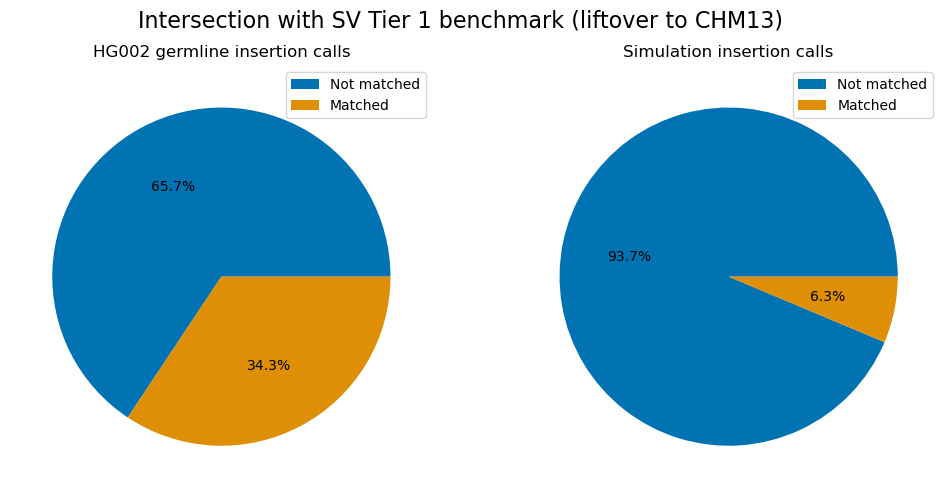

In [15]:
sns.set_style()
fig, ax = plt.subplots(ncols = 2, figsize = (12, 5.5))
ax[0].pie(germline_giab_SVTier1_intersect_ins_all.groupby('SOURCE_SET').size().loc[[',B', 'A,B']], autopct='%1.1f%%', colors = sns.color_palette("colorblind"))
ax[0].set_title("HG002 germline insertion calls", size = 12)
ax[0].legend(labels = ["Not matched", "Matched"])
ax[1].pie(simulation_giab_SVTier1_intersect_ins_all.groupby('SOURCE_SET').size().loc[[',B', 'A,B']], autopct='%1.1f%%', colors = sns.color_palette("colorblind"))
ax[1].set_title("Simulation insertion calls", size = 12)
ax[1].legend(labels = ["Not matched", "Matched"])
plt.suptitle("Intersection with SV Tier 1 benchmark (liftover to CHM13)", size = 16)

## CMRG benchmarking

Text(0.5, 0.98, 'Intersection with CMRG benchmark (liftover to CHM13)')

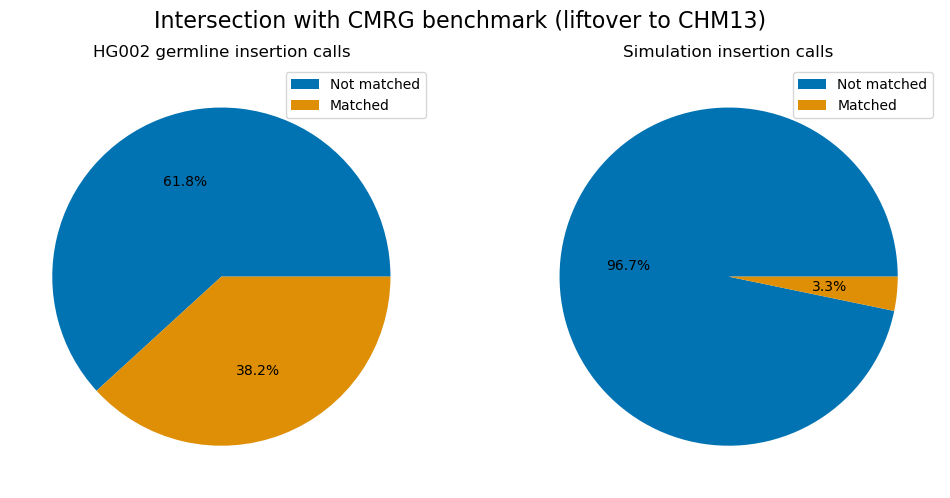

In [16]:
sns.set_style()
fig, ax = plt.subplots(ncols = 2, figsize = (12, 5.5))
ax[0].pie(germline_giab_CMRG_intersect_ins_all.groupby('SOURCE_SET').size().loc[[',B', 'A,B']], autopct='%1.1f%%', colors = sns.color_palette("colorblind"))
ax[0].set_title("HG002 germline insertion calls", size = 12)
ax[0].legend(labels = ["Not matched", "Matched"])
ax[1].pie(simulation_giab_CMRG_intersect_ins_all.groupby('SOURCE_SET').size().loc[[',B', 'A,B']], autopct='%1.1f%%', colors = sns.color_palette("colorblind"))
ax[1].set_title("Simulation insertion calls", size = 12)
ax[1].legend(labels = ["Not matched", "Matched"])
plt.suptitle("Intersection with CMRG benchmark (liftover to CHM13)", size = 16)